# Case Study: Gym Membership Analysis

### Business Problem
A gym owner wants to answer:

- Which membership plan generates the highest revenue?
- Which month had the most new members?
- How are membership fees distributed?
- Do more members lead to higher revenue?
- What percentage of revenue comes from each membership plan?

### Dataset

In [1]:
data = {
    'Month': [
        'Jan','Jan',
        'Feb','Feb',
        'Mar','Mar',
        'Apr','Apr',
        'May','May'
    ],

    'Plan': [
        'Basic','Premium',
        'Basic','Premium',
        'Standard','Premium',
        'Basic','Standard',
        'Premium','Standard'
    ],

    'New_Members': [
        40,20,
        50,25,
        35,30,
        60,40,
        35,45
    ],

    'Fee': [
        1000,2500,
        1000,2500,
        1800,2500,
        1000,1800,
        2500,1800
    ]
}

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.DataFrame(data)

In [4]:
df

,Month,Plan,New_Members,Fee
0,Jan,Basic,40,1000
1,Jan,Premium,20,2500
2,Feb,Basic,50,1000
3,Feb,Premium,25,2500
4,Mar,Standard,35,1800
5,Mar,Premium,30,2500
6,Apr,Basic,60,1000
7,Apr,Standard,40,1800
8,May,Premium,35,2500
9,May,Standard,45,1800


# 

### Task 1: Revenue by Membership Plan

In [5]:
# Calculate Revenue
df['Revenue'] = (df['New_Members'] *df['Fee'])

In [6]:
df

,Month,Plan,New_Members,Fee,Revenue
0,Jan,Basic,40,1000,40000
1,Jan,Premium,20,2500,50000
2,Feb,Basic,50,1000,50000
3,Feb,Premium,25,2500,62500
4,Mar,Standard,35,1800,63000
5,Mar,Premium,30,2500,75000
6,Apr,Basic,60,1000,60000
7,Apr,Standard,40,1800,72000
8,May,Premium,35,2500,87500
9,May,Standard,45,1800,81000


In [7]:
# data preparation
plan_revenue = (df.groupby('Plan')['Revenue'].sum().reset_index())

In [8]:
plan_revenue

,Plan,Revenue
0,Basic,150000
1,Premium,275000
2,Standard,216000


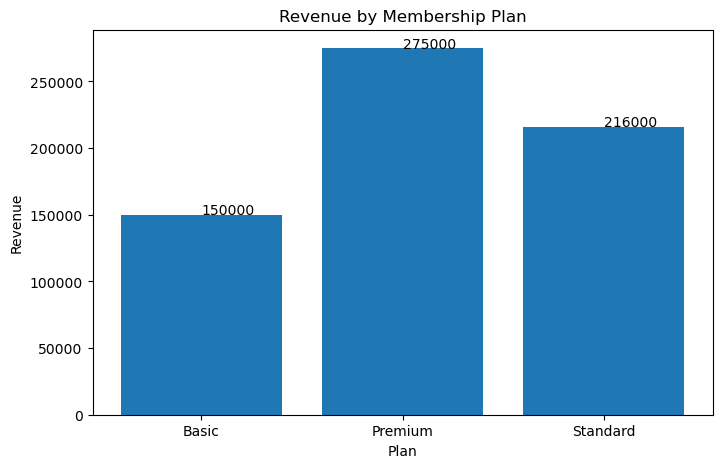

In [13]:
plt.figure(figsize=(8,5))
plt.bar(plan_revenue['Plan'],plan_revenue['Revenue'])
plt.title('Revenue by Membership Plan')
plt.xlabel('Plan')
plt.ylabel('Revenue')
for i, v in enumerate(plan_revenue['Revenue']):
    plt.annotate(v, xy=(i,v))
plt.show()

# 

### Task 2: Monthly New Members

In [14]:
monthly_members = (df.groupby('Month')['New_Members'].sum().reset_index())

In [15]:
monthly_members

,Month,New_Members
0,Apr,100
1,Feb,75
2,Jan,60
3,Mar,65
4,May,80


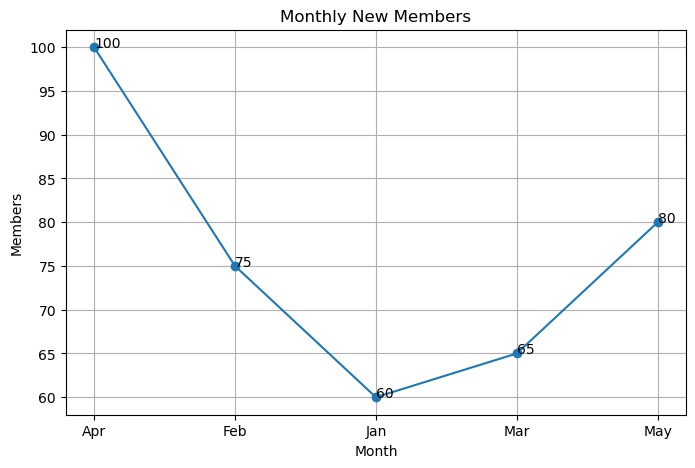

In [21]:
plt.figure(figsize=(8,5))
plt.plot(monthly_members['Month'],monthly_members['New_Members'],marker='o')
plt.title('Monthly New Members')
plt.xlabel('Month')
plt.ylabel('Members')
plt.grid(True)
for i, v in enumerate(monthly_members['New_Members']):
    plt.annotate(v, xy=(i,v))
plt.show()

# 

### Task 3: Membership Fee Distribution
- How are membership fees distributed?

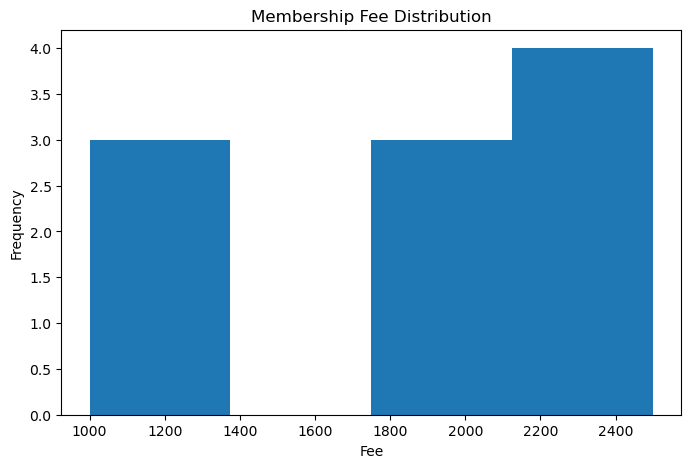

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df['Fee'],bins=4)
plt.title('Membership Fee Distribution')
plt.xlabel('Fee')
plt.ylabel('Frequency')
plt.show()

# 

### Task 4: Members vs Revenue
- Do more members generate more revenue?

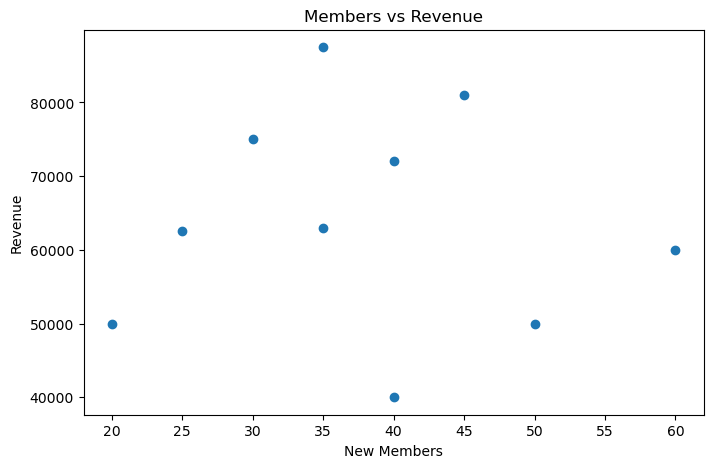

In [27]:
plt.figure(figsize=(8,5))
plt.scatter(df['New_Members'],df['Revenue'])
plt.title('Members vs Revenue')
plt.xlabel('New Members')
plt.ylabel('Revenue')
plt.show()

# 

### Task 5: Revenue Share by Plan

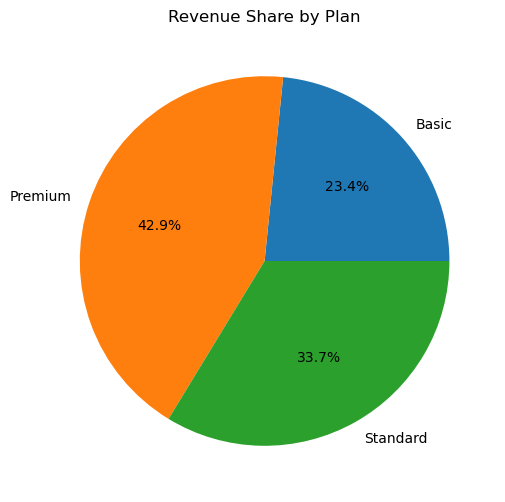

In [29]:
plt.figure(figsize=(6,6))
plt.pie(plan_revenue['Revenue'],labels=plan_revenue['Plan'],autopct='%1.1f%%')
plt.title('Revenue Share by Plan')
plt.show()